## 1. Inicialização dos dados


In [179]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [181]:
# Arquivos anuais — cabeçalho do INMET ocupa 8 linhas; separador ';'; encoding latin1
anos = [2022, 2023, 2024, 2025]
frames = [pd.read_csv(f"dataset/clima/NITEROI {a}.CSV", sep=";",
                      skiprows=8, encoding="latin1") for a in anos]
df = pd.concat(frames, ignore_index=True)

# Coluna fantasma gerada pelo ';' no final de cada linha
df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c])

print(f"Shape bruto: {df.shape}")
df.head(2)

Shape bruto: (35064, 19)


,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2022/01/01,0000 UTC,0,"1008,8","1008,8","1008,2",NaN,"24,7","22,6",25,"24,7","22,8","22,4",89.00,86.00,88.00,66.00,"4,6","1,4"
1,2022/01/01,0100 UTC,",2",1009,"1009,1","1008,7",NaN,"24,6","22,3",25,"24,6","22,7","22,1",89.00,84.00,87.00,74.00,"5,2",",7"


In [182]:
novos_nomes = {
    'Data': 'DATA',
    'Hora UTC': 'HORA_UTC',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)':                          'PRECIPITACAO_MM',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)':    'PRESSAO_ESTACAO_MB',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)':          'PRESSAO_ESTACAO_MAX_H_ANT_MB',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)':         'PRESSAO_ESTACAO_MIN_H_ANT_MB',
    'RADIACAO GLOBAL (Kj/m²)':                                   'RADIACAO_GLOBAL_KJ_M2',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)':             'TEMP_AR_C',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)':                     'TEMP_ORVALHO_C',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)':               'TEMP_MAX_H_ANT_C',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)':               'TEMP_MIN_H_ANT_C',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)':         'TEMP_ORVALHO_MAX_H_ANT_C',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)':         'TEMP_ORVALHO_MIN_H_ANT_C',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)':                 'UMIDADE_REL_MAX_H_ANT_PCT',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)':                 'UMIDADE_REL_MIN_H_ANT_PCT',
    'UMIDADE RELATIVA DO AR, HORARIA (%)':                      'UMIDADE_REL_HORARIA_PCT',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))':                     'VENTO_DIRECAO_GRAUS',
    'VENTO, RAJADA MAXIMA (m/s)':                               'VENTO_RAJADA_MAX_MS',
    'VENTO, VELOCIDADE HORARIA (m/s)':                          'VENTO_VELOCIDADE_MS',
}
df = df.rename(columns=novos_nomes)

In [183]:
# --- Índice temporal ---
idx_data = df.columns.get_loc('DATA')
df.insert(idx_data, 'MES',  pd.to_datetime(df['DATA']).dt.month)

idx_hora = df.columns.get_loc('HORA_UTC')
hora_series = df['HORA_UTC'].astype(str).str.replace(' UTC', '', regex=False).astype(int) // 100
df.insert(idx_hora, 'HORA', hora_series)

df = df.drop(columns=['DATA', 'HORA_UTC'])

# Garante que MES e HORA sejam inteiros do mesmo tipo int
df['MES'] = df['MES'].astype('int64')
df['HORA'] = df['HORA'].astype('int64')

# --- Tipagem numérica ---
# O INMET usa vírgula como separador decimal; '-', 'ND', '-9999' indicam ausência de dado
colunas_numericas = df.columns.difference(['MES', 'HORA'])
for col in colunas_numericas:
    df[col] = (
        df[col].astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .replace(['', '-', 'ND', '-9999.0', '-9999', 'nan'], np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove linhas totalmente vazias (separadores de arquivo do INMET)
df = df.dropna(how='all').reset_index(drop=True)

In [184]:
print(f"Shape após limpeza: {df.shape}")
df.head()

Shape após limpeza: (35064, 19)


,MES,HORA,PRECIPITACAO_MM,PRESSAO_ESTACAO_MB,PRESSAO_ESTACAO_MAX_H_ANT_MB,PRESSAO_ESTACAO_MIN_H_ANT_MB,RADIACAO_GLOBAL_KJ_M2,TEMP_AR_C,TEMP_ORVALHO_C,TEMP_MAX_H_ANT_C,TEMP_MIN_H_ANT_C,TEMP_ORVALHO_MAX_H_ANT_C,TEMP_ORVALHO_MIN_H_ANT_C,UMIDADE_REL_MAX_H_ANT_PCT,UMIDADE_REL_MIN_H_ANT_PCT,UMIDADE_REL_HORARIA_PCT,VENTO_DIRECAO_GRAUS,VENTO_RAJADA_MAX_MS,VENTO_VELOCIDADE_MS
0,1,0,0.00,1008.80,1008.80,1008.20,NaN,24.70,22.60,25.00,24.70,22.80,22.40,89.00,86.00,88.00,66.00,4.60,1.40
1,1,1,0.20,1009.00,1009.10,1008.70,NaN,24.60,22.30,25.00,24.60,22.70,22.10,89.00,84.00,87.00,74.00,5.20,0.70
2,1,2,0.40,1009.30,1009.60,1009.00,NaN,23.40,23.30,24.70,23.30,23.30,22.10,100.00,86.00,100.00,39.00,2.10,0.30
3,1,3,0.20,1007.90,1009.40,1007.90,NaN,24.00,21.10,24.20,23.10,23.30,21.10,100.00,83.00,84.00,75.00,6.20,2.40
4,1,4,0.00,1007.50,1007.90,1007.50,NaN,23.90,20.50,24.00,22.90,21.90,20.20,94.00,79.00,81.00,53.00,6.20,1.30


## 2. Análise Exploratória (EDA)

Inspeciona distribuição, completude e tendência temporal de cada variável.

In [185]:
# Completude por coluna
total = len(df)
missing = df.isnull().sum()
missing_pct = (missing / total * 100).round(2)

resumo_missing = pd.DataFrame({'faltantes': missing, '%': missing_pct})
resumo_missing = resumo_missing[resumo_missing['faltantes'] > 0].sort_values('%', ascending=False)

print(f"Total de registros: {total:,}")
print("\nVariáveis com dados faltantes:")
resumo_missing

Total de registros: 35,064

Variáveis com dados faltantes:


,faltantes,%
RADIACAO_GLOBAL_KJ_M2,16253,46.35
VENTO_RAJADA_MAX_MS,1435,4.09
VENTO_DIRECAO_GRAUS,1420,4.05
VENTO_VELOCIDADE_MS,1420,4.05
TEMP_ORVALHO_MAX_H_ANT_C,356,1.02
UMIDADE_REL_MIN_H_ANT_PCT,356,1.02
TEMP_ORVALHO_MIN_H_ANT_C,357,1.02
UMIDADE_REL_MAX_H_ANT_PCT,354,1.01
TEMP_MIN_H_ANT_C,344,0.98
PRESSAO_ESTACAO_MAX_H_ANT_MB,342,0.98


In [186]:
# Estatísticas descritivas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MES,35064.00,6.52,3.45,1.00,4.00,7.00,10.00,12.00
HORA,35064.00,11.50,6.92,0.00,5.75,11.50,17.25,23.00
PRECIPITACAO_MM,34733.00,0.12,1.05,0.00,0.00,0.00,0.00,62.20
PRESSAO_ESTACAO_MB,34736.00,1015.33,4.86,999.20,1011.80,1015.00,1018.70,1032.20
PRESSAO_ESTACAO_MAX_H_ANT_MB,34722.00,1015.58,4.83,999.40,1012.10,1015.20,1018.90,1032.30
PRESSAO_ESTACAO_MIN_H_ANT_MB,34721.00,1015.08,4.87,998.90,1011.60,1014.70,1018.40,1032.10
RADIACAO_GLOBAL_KJ_M2,18811.00,1267.07,1120.18,0.00,215.40,985.00,2184.80,4202.60
TEMP_AR_C,34734.00,24.83,4.28,12.90,21.90,24.50,27.40,41.30
TEMP_ORVALHO_C,34729.00,19.42,3.29,-3.10,17.20,19.80,21.90,27.60
TEMP_MAX_H_ANT_C,34720.00,25.37,4.44,13.30,22.20,25.00,28.10,42.20


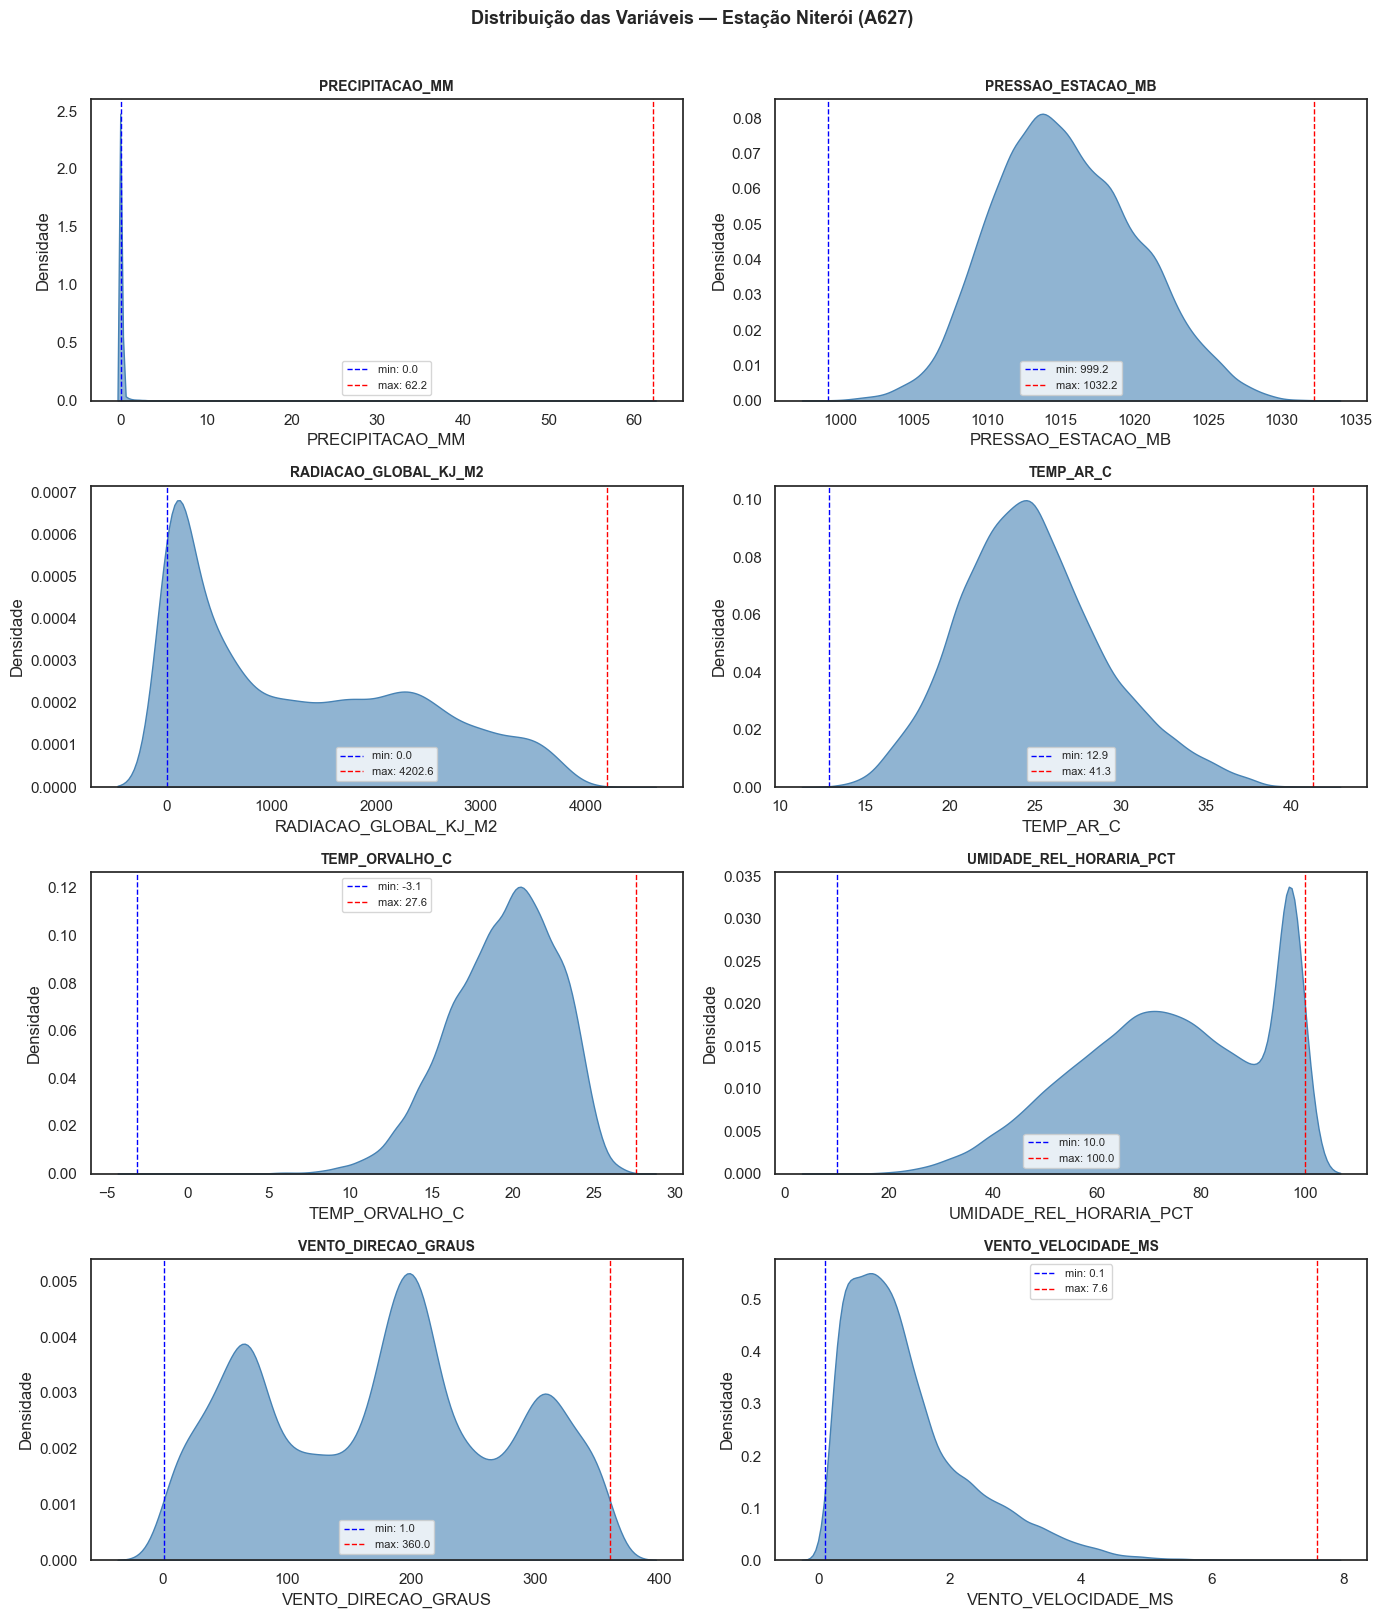

In [187]:
# Distribuição de cada variável (KDE + min/max)
variaveis = [
    'PRECIPITACAO_MM', 'PRESSAO_ESTACAO_MB', 'RADIACAO_GLOBAL_KJ_M2',
    'TEMP_AR_C', 'TEMP_ORVALHO_C', 'UMIDADE_REL_HORARIA_PCT',
    'VENTO_DIRECAO_GRAUS', 'VENTO_VELOCIDADE_MS'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    ax = axes[i]
    data = df[col].dropna()
    sns.kdeplot(data, ax=ax, fill=True, color='steelblue', alpha=0.6)
    ax.axvline(data.min(), color='blue', lw=1, ls='--', label=f'min: {data.min():.1f}')
    ax.axvline(data.max(), color='red',  lw=1, ls='--', label=f'max: {data.max():.1f}')
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis — Estação Niterói (A627)', fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

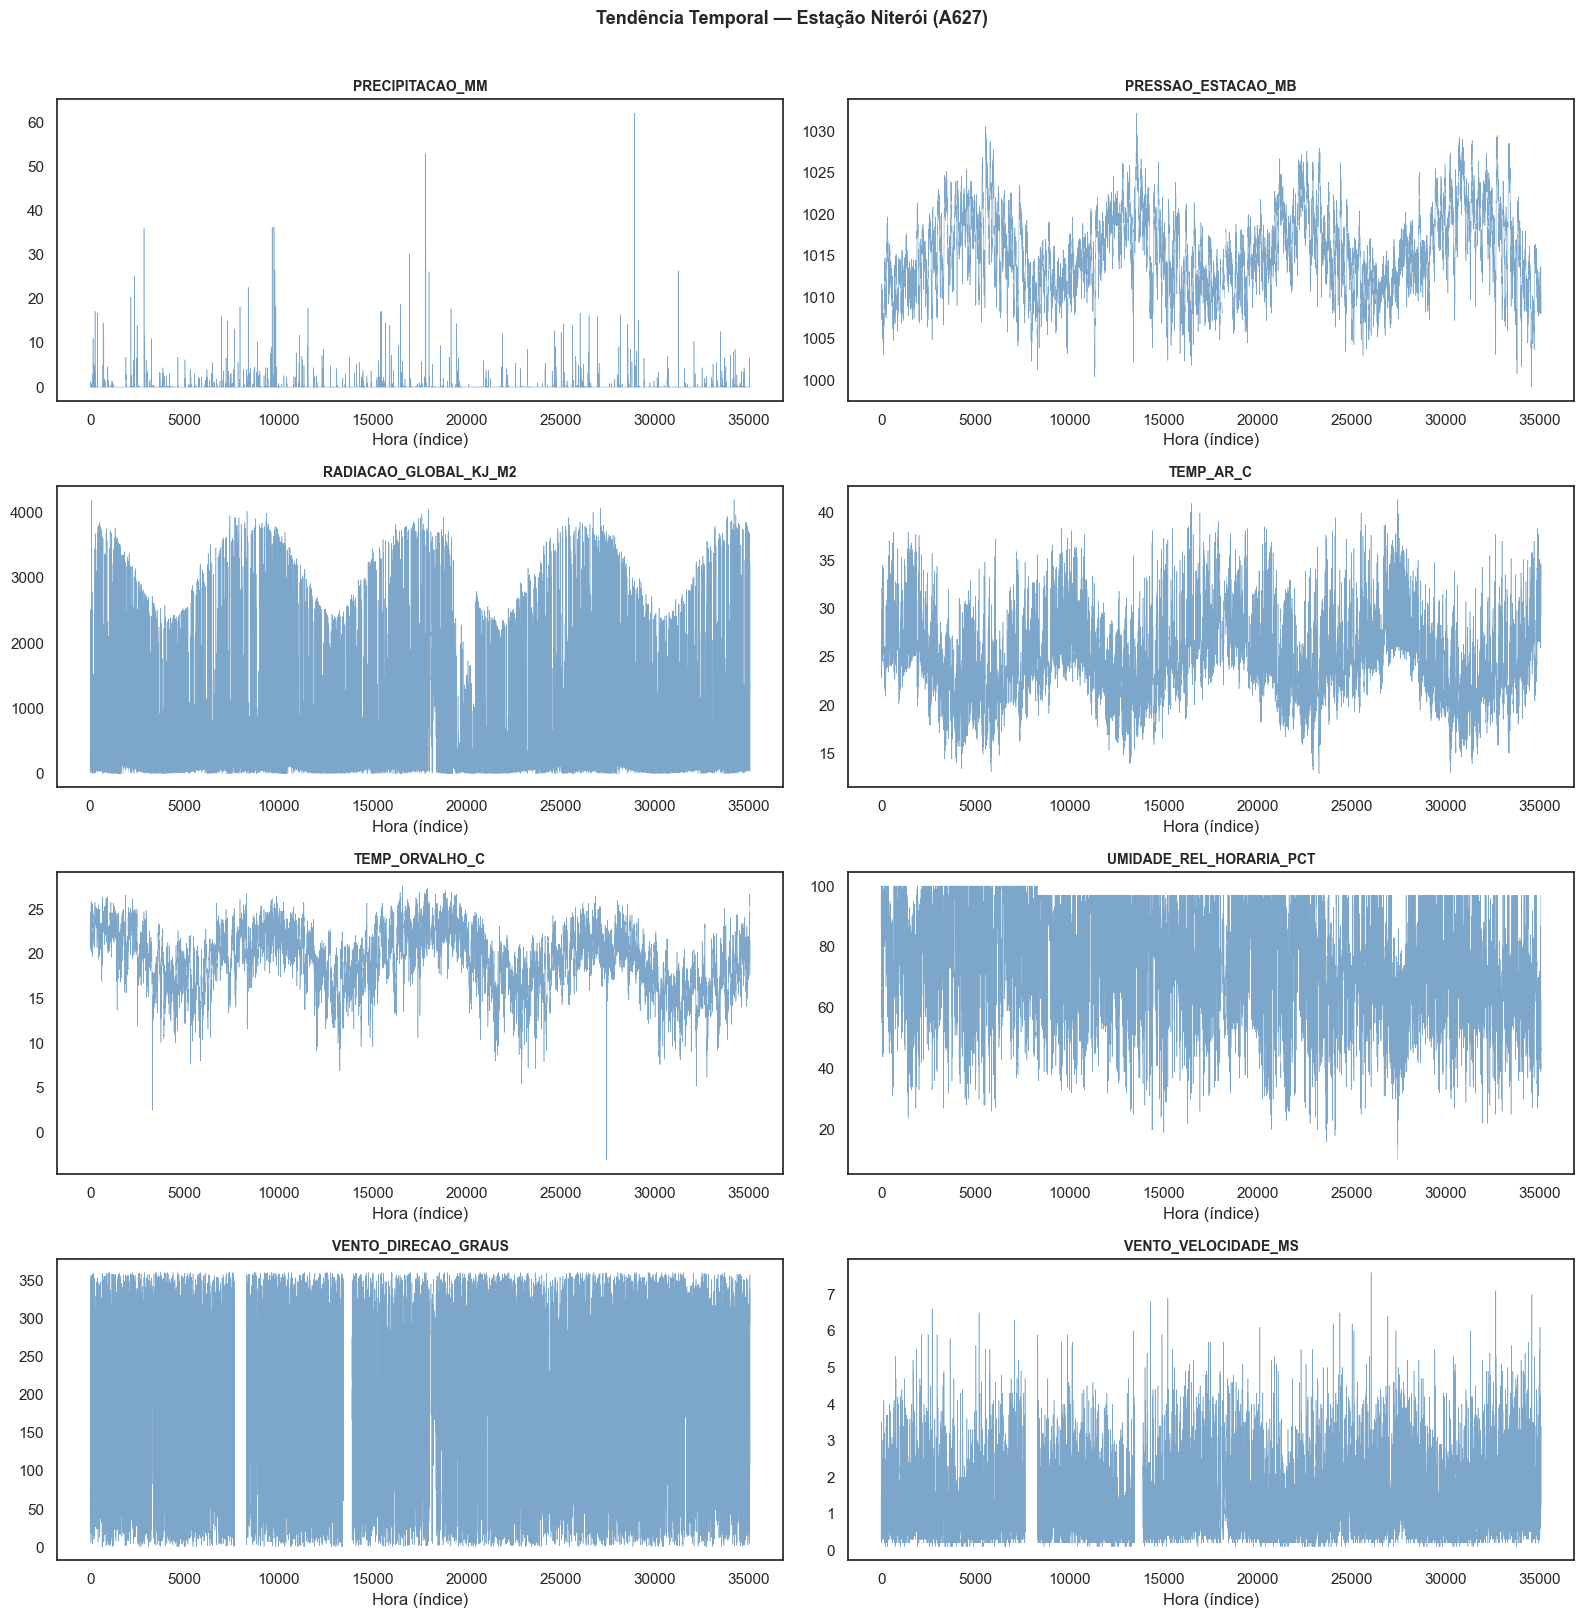

In [188]:
# Tendência temporal — série completa
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    ax = axes[i]
    ax.plot(df.index, df[col].values, lw=0.4, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('Hora (índice)')

plt.suptitle('Tendência Temporal — Estação Niterói (A627)', fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [189]:
# Precipitação é altamente desbalanceada (maioria zero)
# Categorias do Sistema Alerta Rio: Fraca ≤5, Moderada 5–25, Forte >25 mm/h
n_com_chuva = (df['PRECIPITACAO_MM'] > 0).sum()
print(f"Horas com precipitação > 0: {n_com_chuva:,} ({n_com_chuva/len(df)*100:.1f}%)")
print(f"Máximo observado: {df['PRECIPITACAO_MM'].max():.1f} mm/h")
print(f"Percentil 99: {df['PRECIPITACAO_MM'].quantile(0.99):.2f} mm/h")
print(f"Percentil 99.9: {df['PRECIPITACAO_MM'].quantile(0.999):.2f} mm/h")

bins   = [-0.001, 0.0, 5.0, 25.0, np.inf]
labels = ['Sem chuva', 'Fraca (≤5mm/h)', 'Moderada (5–25mm/h)', 'Forte (>25mm/h)']
cat    = pd.cut(df['PRECIPITACAO_MM'], bins=bins, labels=labels)
print("\nDistribuição por categoria Alerta Rio:")
print(cat.value_counts().to_string())

Horas com precipitação > 0: 2,430 (6.9%)
Máximo observado: 62.2 mm/h
Percentil 99: 2.80 mm/h
Percentil 99.9: 15.05 mm/h

Distribuição por categoria Alerta Rio:
PRECIPITACAO_MM
Sem chuva              32303
Fraca (≤5mm/h)          2264
Moderada (5–25mm/h)      153
Forte (>25mm/h)           13


## 3. Pré-processamento

### 3.1 Tratamento de Dados Faltantes

In [190]:
# 1. Remover Radiação Global devido à alta taxa de dados faltantes (46%)
if 'RADIACAO_GLOBAL_KJ_M2' in df.columns:
    df = df.drop(columns=['RADIACAO_GLOBAL_KJ_M2'])

# 2. Preencher a precipitação faltante com 0
# ja que a maioria dos registros são de ausência de chuva, e os dados faltantes provavelmente indicam isso
df['PRECIPITACAO_MM'] = df['PRECIPITACAO_MM'].fillna(0)

# Drop final de segurança para remover qualquer nulo restante no início do dataset
df = df.dropna().reset_index(drop=True)

cols_interp = [
    'PRESSAO_ESTACAO_MB', 'PRESSAO_ESTACAO_MAX_H_ANT_MB', 'PRESSAO_ESTACAO_MIN_H_ANT_MB',
    'TEMP_AR_C', 'TEMP_ORVALHO_C', 'TEMP_MAX_H_ANT_C', 'TEMP_MIN_H_ANT_C',
    'TEMP_ORVALHO_MAX_H_ANT_C', 'TEMP_ORVALHO_MIN_H_ANT_C',
    'UMIDADE_REL_HORARIA_PCT', 'UMIDADE_REL_MAX_H_ANT_PCT', 'UMIDADE_REL_MIN_H_ANT_PCT',
    'VENTO_DIRECAO_GRAUS', 'VENTO_RAJADA_MAX_MS', 'VENTO_VELOCIDADE_MS',
]

for col in cols_interp:
    df[col] = df[col].interpolate(method='linear', limit=3)
    if df[col].isnull().any():
        print(f"Teve NaNs restantes em '{col}' após interpolação linear. Pensar em algum método adicional para preencher esses valores.")
print(f"NaNs restantes: {df.isnull().sum().sum()}")

NaNs restantes: 0


### 3.2 Engenharia de Atributos

Os atributos **hora** e **mês** apresentam natureza cíclica, o que gera descontinuidades artificiais entre 23h e 0h e entre dezembro e janeiro quando representados de forma numérica convencional. Para contornar esse problema, utiliza-se uma transformação senoidal e cossenoidal, proposta por Seber e Wild (1989) no contexto de regressão não linear e amplamente adotada em modelos de previsão de séries temporais meteorológicas (Czernecki et al., 2021, *Atmosphere*).

$$
t_{\text{sen}} = \sin!\left(\frac{2\pi t}{T}\right), \quad
t_{\text{cos}} = \cos!\left(\frac{2\pi t}{T}\right)
$$

com $T = 24$ para a variável **hora** e $T = 12$ para a variável **mês**. Após a transformação, os atributos originais foram removidos, sendo substituídos por suas representações cíclicas.

A direção do vento, expressa em graus, é uma variável circular, o que dificulta seu tratamento por modelos estatísticos e de aprendizado de máquina. Para preservar sua natureza angular, a direção foi convertida em componentes cartesianas utilizando a velocidade do vento:

\begin{aligned}
V_x &= V \cdot \cos(\theta) \
V_y &= V \cdot \sin(\theta)
\end{aligned}

Após a decomposição, o atributo original de direção do vento foi removido.

Por fim, foi construído o atributo déficit de ponto de orvalho, definido como a diferença entre a temperatura do ar e a temperatura do ponto de orvalho:

$$
\Delta T_{\text{orv}} = T_{\text{ar}} - T_{\text{orvalho}}
$$

Esse atributo quantifica a proximidade do ar em relação à saturação de vapor d'água. Valores próximos de zero indicam condições favoráveis à condensação e, consequentemente, à ocorrência de precipitação. Ao final da etapa de engenharia de atributos, foram adicionadas as variáveis **HORA_SEN**, **HORA_COS**, **MES_SEN**, **MES_COS**, **VENTO_X**, **VENTO_Y** e **DEFICIT_ORVALHO_C**.


In [191]:
# --- Codificação cíclica trigonométrica ---
df['HORA_SEN'] = np.sin(2 * np.pi * df['HORA'] / 24)
df['HORA_COS'] = np.cos(2 * np.pi * df['HORA'] / 24)
df['MES_SEN']  = np.sin(2 * np.pi * df['MES']  / 12)
df['MES_COS']  = np.cos(2 * np.pi * df['MES']  / 12)
df = df.drop(columns=['MES', 'HORA'])

# --- Decomposição vetorial do vento ---
theta_rad = np.deg2rad(df['VENTO_DIRECAO_GRAUS'].fillna(0))
df['VENTO_X'] = df['VENTO_VELOCIDADE_MS'] * np.cos(theta_rad)
df['VENTO_Y'] = df['VENTO_VELOCIDADE_MS'] * np.sin(theta_rad)
df = df.drop(columns=['VENTO_DIRECAO_GRAUS'])

# --- Déficit de ponto de orvalho ---
df['DEFICIT_ORVALHO_C'] = df['TEMP_AR_C'] - df['TEMP_ORVALHO_C']

### 3.3 Variável Alvo e Lag Features

O alvo é a precipitação deslocada **+2 horas** no futuro (`shift(-2)`).  
Para capturar padrões sequenciais precursores de chuva — queda de pressão, acúmulo de umidade, resfriamento progressivo — são criadas **lag features** das últimas 6 horas (`t-1` a `t-6`) para as variáveis mais informativas.

In [ ]:
# Variável alvo: precipitação t+2
df['PRECIPITACAO_T2_MM'] = df['PRECIPITACAO_MM'].shift(-2)

# Lag features — histórico das últimas 3 horas
cols_lag = [
    'PRECIPITACAO_MM',
    'PRESSAO_ESTACAO_MB',
    'UMIDADE_REL_HORARIA_PCT',
]

for col in cols_lag:
    for lag in range(1, 4):  # t-1, t-2, t-3
        df[f'{col}_LAG_{lag}'] = df[col].shift(lag)

# Remove bordas
df = df.dropna(subset=['PRECIPITACAO_T2_MM']).copy()
df = df.dropna(subset=[f'{col}_LAG_3' for col in cols_lag]).copy()
df = df.reset_index(drop=True)

print(f"Shape final do dataset: {df.shape}")

Lag features: 9 (3 variáveis × 3 lags)
Shape final do dataset: (33604, 32)


## 4. Análise de Correlação

Correlação de Pearson com a variável alvo.

> Nota: a precipitação tem distribuição extremamente assimétrica, portanto correlações lineares tendem a ser baixas mesmo para variáveis relevantes

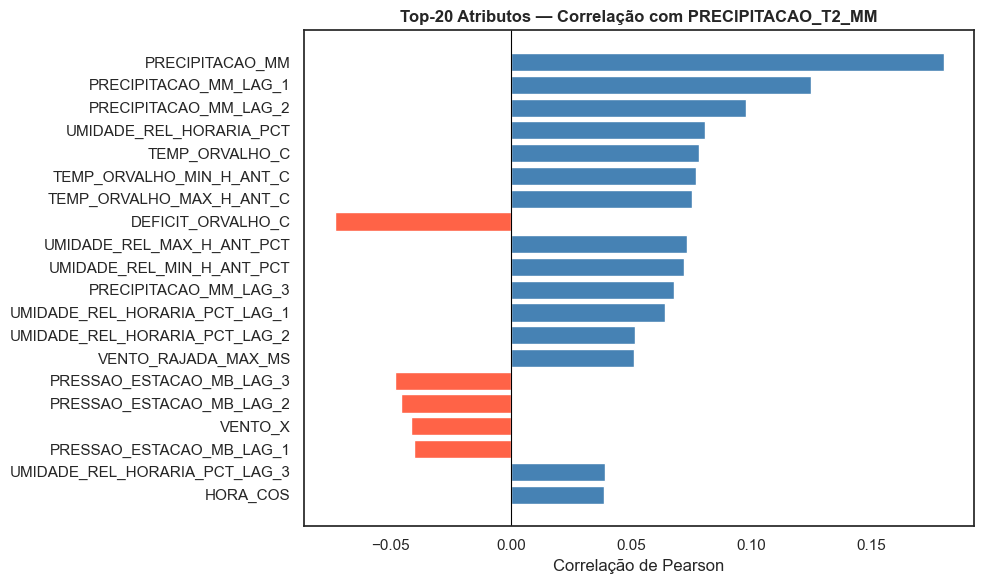

In [ ]:
target = 'PRECIPITACAO_T2_MM'
corr_alvo = (
    df.corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

top20 = corr_alvo.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlação de Pearson')
ax.set_title('Top 20 Atributos — Correlação com PRECIPITACAO_T2_MM', weight='bold')
plt.tight_layout()
plt.show()

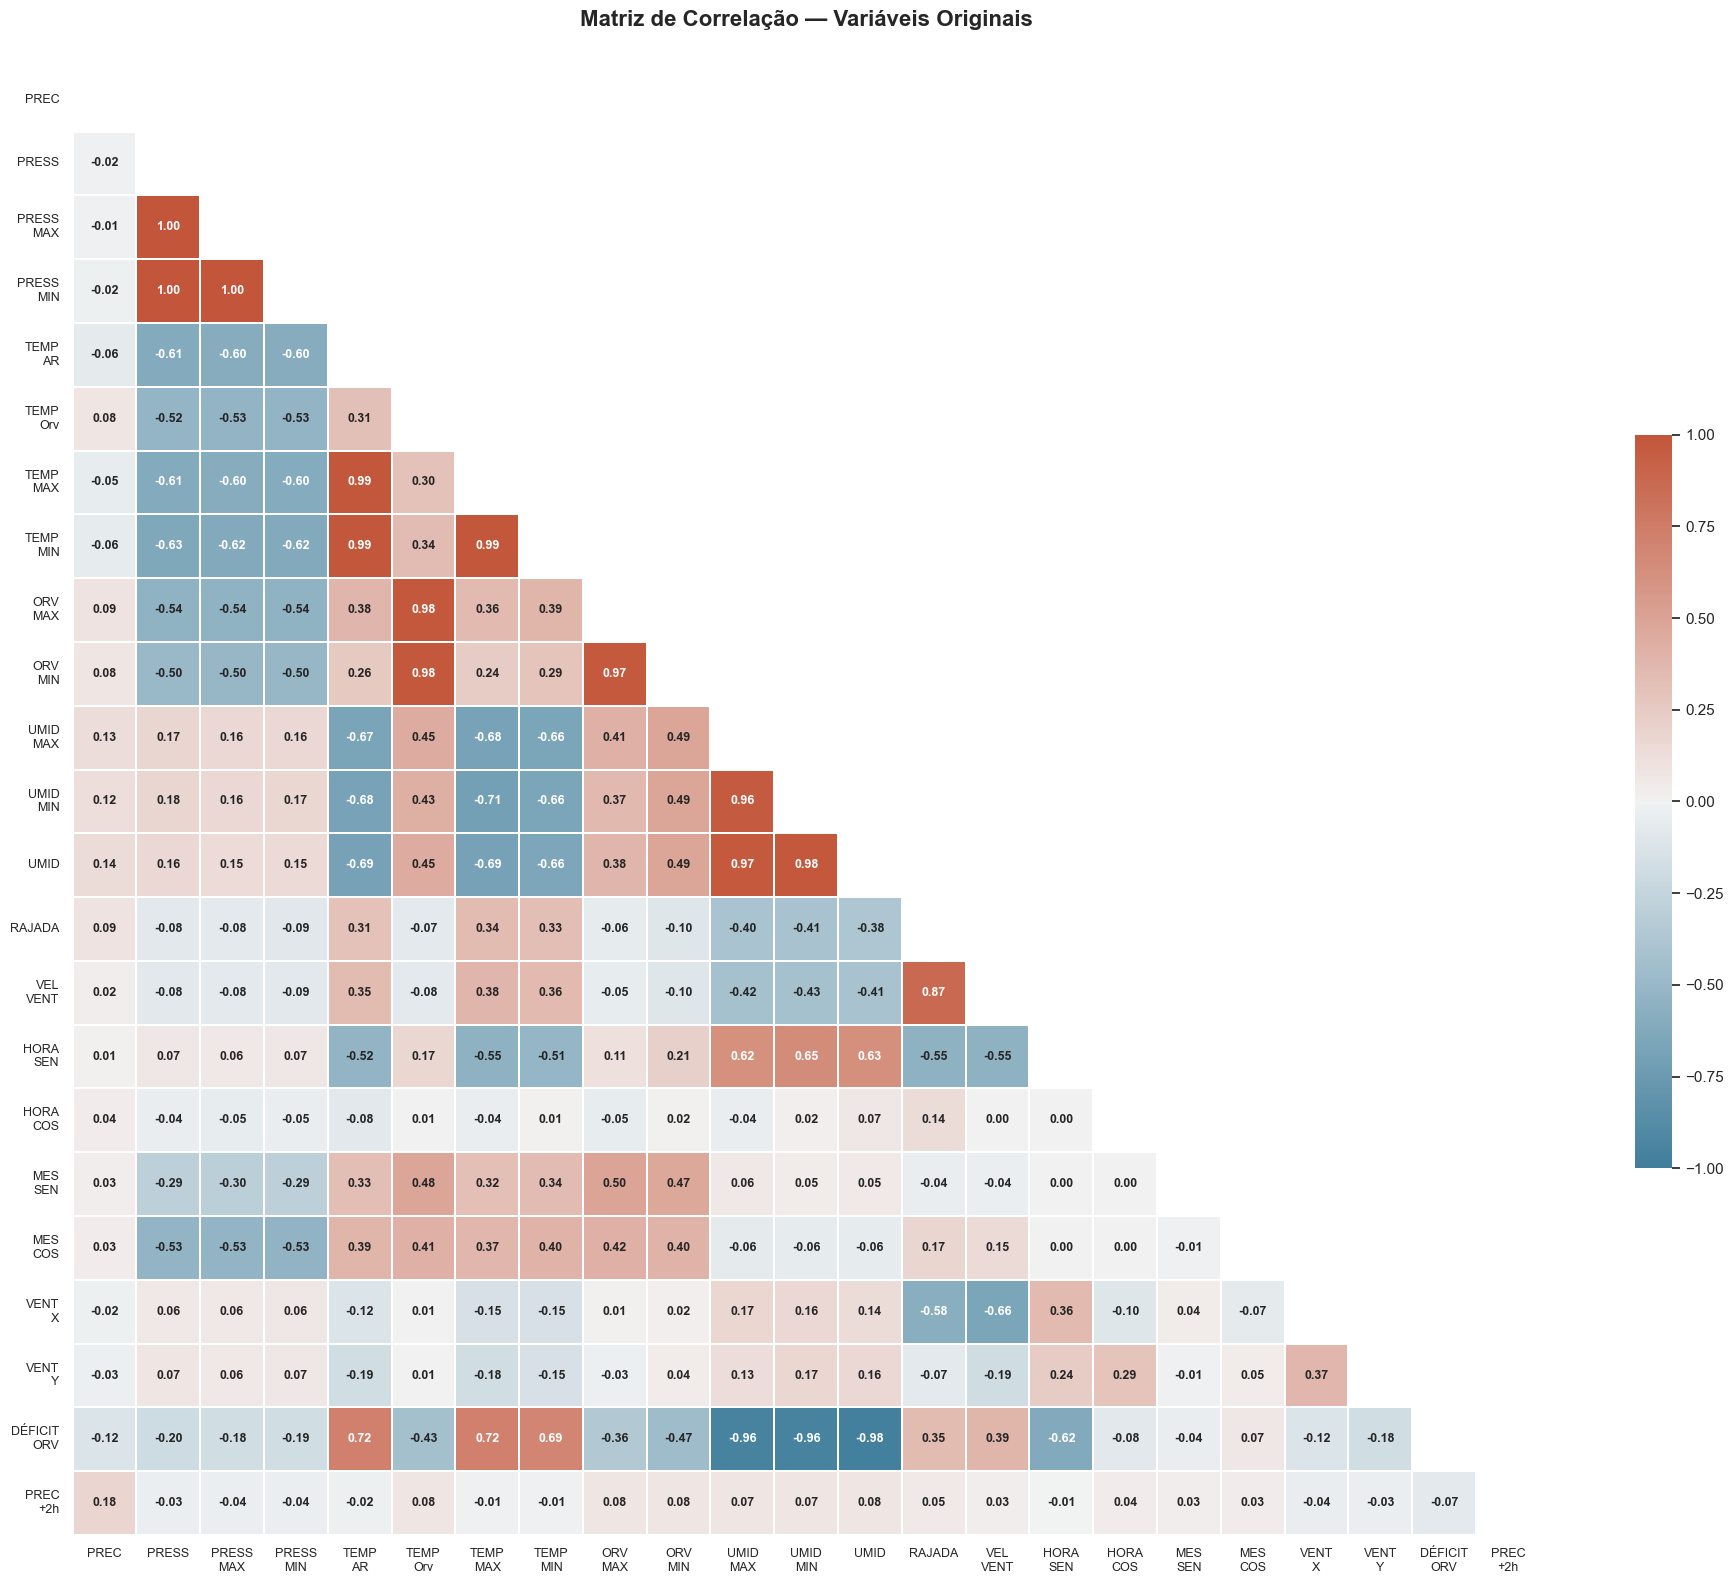

In [194]:
# Matriz de correlação — apenas variáveis originais (sem lags)
nomes_curtos = {
    'PRECIPITACAO_MM':              'PREC',
    'PRECIPITACAO_T2_MM':           'PREC\n+2h',
    'PRESSAO_ESTACAO_MB':           'PRESS',
    'PRESSAO_ESTACAO_MAX_H_ANT_MB': 'PRESS\nMAX',
    'PRESSAO_ESTACAO_MIN_H_ANT_MB': 'PRESS\nMIN',
    'RADIACAO_GLOBAL_KJ_M2':        'RAD',
    'TEMP_AR_C':                    'TEMP\nAR',
    'TEMP_ORVALHO_C':               'TEMP\nOrv',
    'TEMP_MAX_H_ANT_C':             'TEMP\nMAX',
    'TEMP_MIN_H_ANT_C':             'TEMP\nMIN',
    'TEMP_ORVALHO_MAX_H_ANT_C':     'ORV\nMAX',
    'TEMP_ORVALHO_MIN_H_ANT_C':     'ORV\nMIN',
    'UMIDADE_REL_MAX_H_ANT_PCT':    'UMID\nMAX',
    'UMIDADE_REL_MIN_H_ANT_PCT':    'UMID\nMIN',
    'UMIDADE_REL_HORARIA_PCT':      'UMID',
    'VENTO_RAJADA_MAX_MS':          'RAJADA',
    'VENTO_VELOCIDADE_MS':          'VEL\nVENT',
    'VENTO_X':                      'VENT\nX',
    'VENTO_Y':                      'VENT\nY',
    'DEFICIT_ORVALHO_C':            'DÉFICIT\nORV',
    'HORA_SEN':                     'HORA\nSEN',
    'HORA_COS':                     'HORA\nCOS',
    'MES_SEN':                      'MES\nSEN',
    'MES_COS':                      'MES\nCOS',
}

cols_orig = [c for c in df.columns if '_LAG_' not in c]
cols_orig = [c for c in cols_orig if c != target] + [target]

df_corr = df[cols_orig].rename(columns=nomes_curtos)
matriz = df_corr.corr()
matriz[np.abs(matriz) < 0.005] = 0.0

sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(matriz, dtype=bool), k=0)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    matriz, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
    square=True, linewidths=1.2, annot=True, fmt='.2f',
    cbar_kws={'shrink': 0.5}, annot_kws={'size': 9, 'weight': 'bold'}, ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right',  fontsize=9)
ax.set_title('Matriz de Correlação — Variáveis Originais', fontsize=16, weight='bold', pad=30)
plt.tight_layout()
plt.show()

## 5. Divisão Temporal

A divisão é estritamente cronológica, embaralhar violaria a estrutura temporal.
| Conjunto   | Proporção | Uso |
|------------|-----------|-----|
| Treino     | 70%       | Ajuste dos parâmetros |
| Validação  | 15%       | Seleção de hiperparâmetros |
| Teste      | 15%       | Avaliação final  |

In [195]:
n = len(df)
n_treino = int(n * 0.70)
n_val    = int(n * 0.15)

df_treino = df.iloc[:n_treino].copy()
df_val    = df.iloc[n_treino : n_treino + n_val].copy()
df_teste  = df.iloc[n_treino + n_val :].copy()

print(f"Treino:    {len(df_treino):,} ({len(df_treino)/n*100:.1f}%)")
print(f"Validação: {len(df_val):,} ({len(df_val)/n*100:.1f}%)")
print(f"Teste:     {len(df_teste):,} ({len(df_teste)/n*100:.1f}%)")

for nome, split in [('Treino', df_treino), ('Validação', df_val), ('Teste', df_teste)]:
    pct = (split['PRECIPITACAO_T2_MM'] > 0).mean() * 100
    print(f"  {nome}: {pct:.1f}% horas com chuva | média = {split['PRECIPITACAO_T2_MM'].mean():.3f} mm/h")

Treino:    23,522 (70.0%)
Validação: 5,040 (15.0%)
Teste:     5,042 (15.0%)
  Treino: 7.5% horas com chuva | média = 0.127 mm/h
  Validação: 6.4% horas com chuva | média = 0.130 mm/h
  Teste: 5.9% horas com chuva | média = 0.074 mm/h


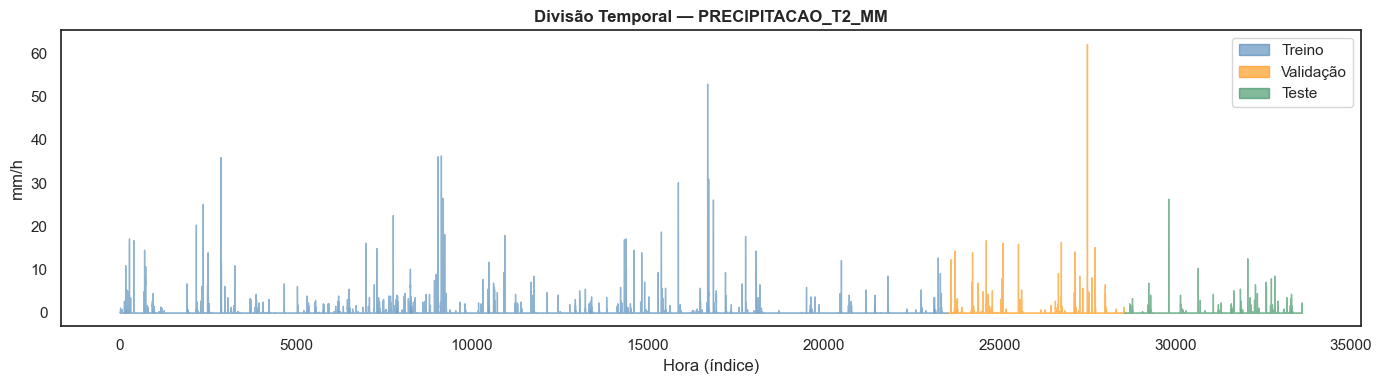

In [196]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(df_treino)),
                df_treino['PRECIPITACAO_T2_MM'].values,
                color='steelblue', alpha=0.6, label='Treino')
ax.fill_between(range(len(df_treino), len(df_treino) + len(df_val)),
                df_val['PRECIPITACAO_T2_MM'].values,
                color='darkorange', alpha=0.6, label='Validação')
ax.fill_between(range(len(df_treino) + len(df_val), n),
                df_teste['PRECIPITACAO_T2_MM'].values,
                color='seagreen', alpha=0.6, label='Teste')
ax.set_title('Divisão Temporal — PRECIPITACAO_T2_MM', weight='bold')
ax.set_xlabel('Hora (índice)')
ax.set_ylabel('mm/h')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Padronização

Após a divisão temporal dos dados em treino, validação e teste, foi realizada a padronização das variáveis preditoras. Esse procedimento tem como objetivo colocar todas as features em uma escala comparável, evitando que atributos com magnitudes maiores exerçam influência desproporcional durante o treinamento dos modelos.

A padronização foi realizada utilizando a transformação Z-score:
$$
X_p = \frac{X - \mu_{\text{treino}}}{\sigma_{\text{treino}}}
$$
em que $\mu_{\text{treino}}$ e $\sigma_{\text{treino}}$ representam, respectivamente, a média e o desvio padrão calculados exclusivamente sobre o conjunto de treinamento.

O cálculo das estatísticas apenas no conjunto de treino evita o vazamento de informação, situação em que dados de validação ou teste influenciam indiretamente o processo de treinamento. Após o cálculo dessas estatísticas, a mesma transformação foi aplicada aos conjuntos de validação e teste.

A variável alvo, PRECIPITACAO_T2_MM, não foi padronizada e permaneceu em sua unidade original (milímetros de precipitação). Essa decisão foi adotada porque os modelos de regressão baseados em árvores utilizados neste trabalho, como Random Forest e Gradient Boosting, são pouco sensíveis à escala da variável alvo. Além disso, manter a precipitação na escala original facilita a interpretação dos resultados, permitindo que métricas como MAE e RMSE sejam analisadas diretamente em milímetros de chuva previstos para as próximas duas horas.

Como verificação do procedimento, foram calculadas a média e o desvio padrão das features no conjunto de treinamento após a transformação, obtendo-se valores próximos de 0 e 1, respectivamente, conforme esperado para uma padronização correta.


In [197]:
FEATURE_COLS = [c for c in df.columns if c != 'PRECIPITACAO_T2_MM']
TARGET_COL   = 'PRECIPITACAO_T2_MM'

# Estatísticas calculadas apenas no treino
mu_treino    = df_treino[FEATURE_COLS].mean()
sigma_treino = df_treino[FEATURE_COLS].std().replace(0, 1)  # evita divisão por zero

def padronizar(split):
    split = split.copy()
    split[FEATURE_COLS] = (split[FEATURE_COLS] - mu_treino) / sigma_treino
    return split

df_treino_p = padronizar(df_treino)
df_val_p    = padronizar(df_val)
df_teste_p  = padronizar(df_teste)

# Verificação: média e std das features no treino padronizado
print("Treino padronizado — média das features (esperado ≈ 0):")
print(df_treino_p[FEATURE_COLS].mean().describe().round(4))
print("\nTreino padronizado — std das features (esperado ≈ 1):")
print(df_treino_p[FEATURE_COLS].std().describe().round(4))

Treino padronizado — média das features (esperado ≈ 0):
count   31.00
mean     0.00
std      0.00
min     -0.00
25%     -0.00
50%      0.00
75%      0.00
max      0.00
dtype: float64

Treino padronizado — std das features (esperado ≈ 1):
count   31.00
mean     1.00
std      0.00
min      1.00
25%      1.00
50%      1.00
75%      1.00
max      1.00
dtype: float64


## 7. Preparação Final dos Dados

Após a etapa de padronização, os dados foram separados em variáveis preditoras (X) e variável alvo (y) para cada conjunto de treino, validação e teste. Em seguida, foram realizadas verificações da dimensionalidade do conjunto de dados, incluindo a quantidade total de atributos, a distinção entre variáveis originais e lag features, e o tamanho de cada partição.

Por fim, os conjuntos processados foram exportados para arquivos CSV, permitindo sua reutilização na etapa de treinamento e avaliação dos modelos. Também foram armazenados os parâmetros de padronização (média e desvio padrão calculados no conjunto de treino), possibilitando a aplicação da mesma transformação a novos dados durante a inferência.

In [200]:
X_treino, y_treino = df_treino_p[FEATURE_COLS], df_treino_p[TARGET_COL]
X_val,    y_val    = df_val_p[FEATURE_COLS],    df_val_p[TARGET_COL]
X_teste,  y_teste  = df_teste_p[FEATURE_COLS],  df_teste_p[TARGET_COL]

print("=== Dataset pronto para modelagem ===")
print(f"Features totais : {len(FEATURE_COLS)}")
print(f"  Originais     : {len([c for c in FEATURE_COLS if '_LAG_' not in c])}")
print(f"  Lag features  : {len([c for c in FEATURE_COLS if '_LAG_' in c])}")
print(f"X_treino : {X_treino.shape}")
print(f"X_val    : {X_val.shape}")
print(f"X_teste  : {X_teste.shape}")

# Exporta splits prontos para uso no notebook de modelagem
df_treino_p.to_csv('dataset/treino.csv', index=False)
df_val_p.to_csv('dataset/validacao.csv', index=False)
df_teste_p.to_csv('dataset/teste.csv',   index=False)

# Salva parâmetros de padronização para uso na inferência
pd.DataFrame({'media': mu_treino, 'std': sigma_treino}).to_csv('dataset/scaler_params.csv')
print("\nArquivos salvos em dataset/: treino.csv | validacao.csv | teste.csv | scaler_params.csv")

=== Dataset pronto para modelagem ===
Features totais : 31
  Originais     : 22
  Lag features  : 9
X_treino : (23522, 31)
X_val    : (5040, 31)
X_teste  : (5042, 31)

Arquivos salvos em dataset/: treino.csv | validacao.csv | teste.csv | scaler_params.csv


In [ ]:
# Resumo das features por grupo
grupos = {
    'Temporais (cíclicas)':  [c for c in FEATURE_COLS if any(s in c for s in ['HORA_', 'MES_'])],
    'Precipitação':          [c for c in FEATURE_COLS if 'PRECIPITACAO' in c],
    'Pressão':               [c for c in FEATURE_COLS if 'PRESSAO' in c],
    'Temperatura':           [c for c in FEATURE_COLS if 'TEMP' in c],
    'Umidade':               [c for c in FEATURE_COLS if 'UMIDADE' in c],
    'Vento':                 [c for c in FEATURE_COLS if 'VENTO' in c],
    'Construídas':           [c for c in FEATURE_COLS if c == 'DEFICIT_ORVALHO_C'],
}

print(f"{'Grupo':<30} {'Qtd':>5}")
print('-' * 37)
for g, cols in grupos.items():
    print(f"{g:<30} {len(cols):>5}")
print('-' * 37)
print(f"{'TOTAL':<30} {len(FEATURE_COLS):>5}")

Grupo                            Qtd
-------------------------------------
Temporais (cíclicas)               4
Precipitação                       4
Pressão                            6
Temperatura                        6
Umidade                            6
Vento                              4
Radiação                           0
Construídas                        1
-------------------------------------
TOTAL                             31
